# Petal counting in cut chrysanthemum with SE-CSRNet (density regression)

Reproduction of the released inference pipeline from:

> **Deep learning-driven automatic counting of petal number in cut chrysanthemum inflorescence.** Plant Phenomics 8(3):100238 (2026). DOI: [10.1016/j.plaphe.2026.100238](https://doi.org/10.1016/j.plaphe.2026.100238)

- **Author code (pinned):** https://github.com/qwsdfgz/petalscount @ commit `fd935c9b8682c9494d9ba36348d7dd364d3eeffa`
- **Scope:** run the authors' `test.py` inference — SE-CSRNet density prediction on the **70 bundled test images**, compare predicted counts (density-map integral) with ground-truth counts (ground-truth `.h5` density integrals), report MAE/MSE/RMSE, and visualize one example.
- **Out of scope** (inputs not released by the authors): model training, the second-stage random-forest calibration, and the heat-stress statistical analysis. A single-test-set inference is not a full-paper reproduction.
- **Execution status:** this notebook was fully executed on a fresh Google Colab **T4 GPU** runtime (see saved outputs). It requires a GPU runtime and fails clearly on CPU-only runtimes.

**日本語:** 本ノートブックは著者公開リポジトリ `qwsdfgz/petalscount` の推論パイプライン（SE-CSRNet）を、バンドルされた70枚のテスト画像と正解密度マップで再現します。学習・ランダムフォレスト較正・熱ストレス統計は対象外です。実行には GPU (T4) ランタイムを選択してください。

In [ ]:
import subprocess, sys

# The method is CNN inference over ~2000x1500 images; a GPU runtime is required.
# Verify the allocated accelerator BEFORE any heavy setup and fail clearly on CPU-only runtimes.
nvidia = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'],
                        capture_output=True, text=True)
if nvidia.returncode != 0 or not nvidia.stdout.strip():
    raise RuntimeError('No GPU detected. Use Runtime > Change runtime type > T4 GPU. '
                       'CPU inference for all 70 images would take ~30+ minutes and is not validated.')
print('GPU:', nvidia.stdout.strip())
print('Python:', sys.version)

GPU: Tesla T4, 15360 MiB
Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


## 1. Environment

The authors' README pins Python 3.10.14, PyTorch 2.4.0, torchvision 0.19.0, numpy 1.23.5. Current Colab runtimes use **Python 3.13**, for which no torch 2.4.0 wheels are published (installation verified to fail), so this notebook uses the runtime's preinstalled torch/torchvision and records the actual versions; the scientific operations are unchanged. `h5py`, `pandas`, `matplotlib` are preinstalled. A **GPU (T4) runtime is required**.

**日本語:** 著者は torch 2.4.0 を指定していますが、現在のColab(Python 3.13)では導入できないため、ランタイム標準の torch をそのまま使用し、実バージョンを記録します。GPU (T4) ランタイムが必要です。

In [ ]:
import torch, torchvision, numpy as np, sys
# The authors pin torch 2.4.0 on Python 3.10; current Colab runs Python 3.13, where no
# torch 2.4.0 wheels exist (verified: pip install fails). The scientific math is unchanged,
# so we use the runtime's preinstalled torch/torchvision and record the actual versions.
assert torch.cuda.is_available(), 'CUDA unavailable: select Runtime > Change runtime type > T4 GPU'
print('Python:', sys.version.split()[0])
print('torch', torch.__version__, '| torchvision', torchvision.__version__, '| numpy', np.__version__)
print('GPU:', torch.cuda.get_device_name(0), '| torch built with CUDA:', torch.version.cuda)

Python: 3.13.15
torch 2.11.0+cu130 | torchvision 0.26.0+cu130 | numpy 2.1.3
GPU: Tesla T4 | torch built with CUDA: 13.0


## 2. Data and weights acquisition (pinned commit, inside Colab only)

All test inputs come from the authors' repository at the pinned commit. We use a **partial clone with sparse checkout** of only `images/` and `gt/`, with Git LFS smudging disabled. Git verifies blob integrity, and we assert the checked-out commit equals the pin. Expected content: 70 `.jpg` test images (≈3.4 MB total) and 71 ground-truth `.h5` density maps (≈3.1 MB each; one GT has no matching image and is unused by `test.py`).

**日本語:** 著者リポジトリの固定コミットから、部分クローン＋スパースチェックアウトで `images/` と `gt/` のみ取得します（LFSは後段）。

In [ ]:
import os, subprocess

REPO = 'https://github.com/qwsdfgz/petalscount.git'
PIN = 'fd935c9b8682c9494d9ba36348d7dd364d3eeffa'
WORK = '/content/petalscount'

def run(cmd, **kw):
    r = subprocess.run(cmd, shell=isinstance(cmd, str), check=True, text=True,
                       capture_output=True, **kw)
    return r.stdout.strip()

subprocess.run(['apt-get', 'install', '-y', '-qq', 'git-lfs'], check=True, capture_output=True)
subprocess.run(['git', 'lfs', 'install'], check=True, capture_output=True)
env = dict(os.environ, GIT_LFS_SKIP_SMUDGE='1')
if os.path.exists(WORK):
    subprocess.run(['rm', '-rf', WORK], check=True)
run(['git', 'clone', '--filter=blob:none', '--no-checkout', '--depth', '1', REPO, WORK], env=env)
run(['git', 'fetch', '--depth', '1', 'origin', PIN], cwd=WORK, env=env)
run('git sparse-checkout init --cone && git sparse-checkout set images gt', cwd=WORK)
run(['git', 'checkout', 'FETCH_HEAD'], cwd=WORK, env=env)
head = run(['git', 'rev-parse', 'HEAD'], cwd=WORK)
assert head == PIN, f'checked-out commit {head} != pinned {PIN}'
jpgs = sorted(f for f in os.listdir(f'{WORK}/images') if f.lower().endswith('.jpg'))
h5s = sorted(f for f in os.listdir(f'{WORK}/gt') if f.endswith('.h5'))
print('HEAD:', head)
print(f'test images: {len(jpgs)}, gt density maps: {len(h5s)}')
assert len(jpgs) == 70 and len(h5s) == 70, (len(jpgs), len(h5s))
# gt/ also contains the authors' test.txt; every one of the 70 images has a paired .h5
print('example files:', jpgs[:2])

HEAD: fd935c9b8682c9494d9ba36348d7dd364d3eeffa
test images: 70, gt density maps: 70
example files: ['Q1-105_IMG_9614.jpg', 'Q1-108_IMG_0076.jpg']


## 3. Model weights (Git LFS payload)

`0model_best.pth.tar` is stored via **Git LFS** (134-byte pointer in the repo). We pull the real payload explicitly for this single file, then verify it is a loadable checkpoint and summarize its `state_dict` keys (the authors' `test.py` filters out `thop` FLOPs entries `.total_ops/.total_params` and loads with `strict=False`).

**日本語:** 重みはLFSで管理されているため、`git lfs pull` で実体のみ取得し、チェックポイントを読み込めることを確認します。

In [ ]:
import pathlib
CKPT = f'{WORK}/0model_best.pth.tar'
run(['git', 'lfs', 'pull', '-I', '0model_best.pth.tar'], cwd=WORK)
size = pathlib.Path(CKPT).stat().st_size
assert size > 1_000_000, f'weights still an LFS pointer ({size} B); LFS pull failed'
print(f'0model_best.pth.tar: {size/1e6:.1f} MB')
import torch
ckpt = torch.load(CKPT, weights_only=True)
print('checkpoint top-level keys:', list(ckpt.keys()))
keys = list(ckpt['state_dict'].keys())
print(f'state_dict entries: {len(keys)}; first: {keys[0]}; last: {keys[-1]}')

0model_best.pth.tar: 193.2 MB


checkpoint top-level keys: ['epoch', 'arch', 'state_dict', 'best_prec1', 'optimizer']
state_dict entries: 54; first: total_ops; last: output_layer.bias


## 4. Model definition — author code, imported from the pinned commit

We import `CSRNet` (SE-CSRNet: VGG16 first-10-layer frontend → SE attention (512→32→512) → dilated backend (rate 2) → 1×1 output) **directly from the cloned author file** `/content/petalscount/model.py`. Instantiation copies ImageNet VGG16 weights into the frontend exactly as the authors' code does (a one-time torchvision download), then the released checkpoint overwrites all layers. The only adaptation to `test.py` is explicit device selection (GPU required).

**日本語:** モデル定義は著者の `model.py` をそのままクローンから import します（VGG16 ImageNet 重みのコピーも元コードどおり）。

In [ ]:
import sys, time
sys.path.insert(0, WORK)
from model import CSRNet  # author code, pinned commit fd935c9

t0 = time.time()
model = CSRNet().cuda()  # faithful to test.py; GPU runtime required
device = torch.device('cuda')
ckpt = torch.load(CKPT, weights_only=True)
filtered = {k: v for k, v in ckpt['state_dict'].items()
            if not k.endswith(('.total_ops', '.total_params'))}
missing, unexpected = model.load_state_dict(filtered, strict=False)
model.eval()
print(f'loaded: {len(filtered)} tensors, missing={len(missing)}, unexpected={len(unexpected)}, {time.time()-t0:.0f}s')
# unexpected thop entries are ignored by the authors' strict=False; verify none are model weights
assert all(k in ('total_ops', 'total_params') for k in unexpected)

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


  0%|          | 0.00/528M [00:00<?, ?B/s]

  2%|▏         | 9.75M/528M [00:00<00:05, 102MB/s]

  4%|▍         | 21.9M/528M [00:00<00:04, 116MB/s]

...

 93%|█████████▎| 490M/528M [00:03<00:00, 173MB/s]

 96%|█████████▌| 507M/528M [00:03<00:00, 171MB/s]

100%|█████████▉| 526M/528M [00:03<00:00, 178MB/s]

100%|██████████| 528M/528M [00:03<00:00, 138MB/s]

loaded: 50 tensors, missing=0, unexpected=2, 6s


## 5. Input preview — image with its ground-truth density map

Before inference, we show one actual test input with its **author-provided ground-truth density map** (from `gt/*.h5`, dataset key `density`). The GT petal count is the density integral; the color overlay is the annotation the model is evaluated against.

**日本語:** 推論前に、実テスト画像と著者提供の正解密度マップ（`gt/*.h5` の `density`）を表示します。正解個体数は密度マップの積分値です。

Q1-105_IMG_9614.jpg: image 1024x768 px, density map (768, 1024), GT count = 21.0


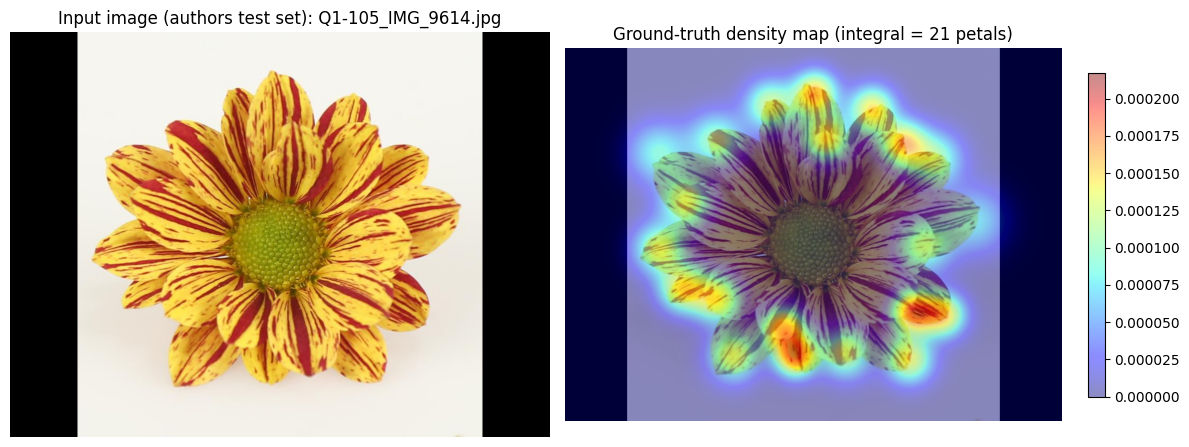

In [ ]:
import h5py, numpy as np
import matplotlib.pyplot as plt
from PIL import Image

EXAMPLE = 'Q1-105_IMG_9614.jpg'  # first test image (sorted)
img = Image.open(f'{WORK}/images/{EXAMPLE}').convert('RGB')
with h5py.File(f'{WORK}/gt/{EXAMPLE[:-4]}.h5', 'r') as hf:
    gt_map = np.array(hf['density'], dtype=np.float32)
print(f'{EXAMPLE}: image {img.size[0]}x{img.size[1]} px, density map {gt_map.shape}, GT count = {gt_map.sum():.1f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img); axes[0].set_title(f'Input image (authors test set): {EXAMPLE}'); axes[0].axis('off')
axes[1].imshow(img)
im = axes[1].imshow(gt_map, cmap='jet', alpha=0.45)
axes[1].set_title(f'Ground-truth density map (integral = {gt_map.sum():.0f} petals)')
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.03)
plt.tight_layout(); plt.show()

## 6. Inference on all 70 test images (authors' `test.py` procedure)

Each image is normalized with ImageNet statistics, passed through SE-CSRNet, and the **predicted count is the sum of the predicted density map**; the ground truth is the sum of the GT density map. We keep the authors' math identical; the loop records per-image results and a running MAE, and reports progress every 10 images.

**日本語:** `test.py` の処理（ImageNet正規化 → 密度マップ推定 → 積分で個体数）を全70枚に適用し、経過を表示しながら実行します。

In [ ]:
import torchvision.transforms as T
import pandas as pd

transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
rows = []
t0 = time.time()
for i, name in enumerate(jpgs, 1):
    img_pil = Image.open(f'{WORK}/images/{name}').convert('RGB')
    inp = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        density = model(inp).squeeze().cpu().numpy()
    pred_cnt = float(density.sum())
    with h5py.File(f'{WORK}/gt/{name[:-4]}.h5', 'r') as hf:
        gt_cnt = float(np.array(hf['density'], dtype=np.float32).sum())
    rows.append({'image': name, 'predicted': pred_cnt, 'ground_truth': gt_cnt,
                 'abs_error': abs(pred_cnt - gt_cnt)})
    if i % 10 == 0 or i == len(jpgs):
        print(f'{i}/{len(jpgs)} images, running MAE = {np.mean([r["abs_error"] for r in rows]):.2f}, {time.time()-t0:.0f}s')
results = pd.DataFrame(rows)
print(f'inference wall time: {time.time()-t0:.0f}s on {torch.cuda.get_device_name(0)}')

10/70 images, running MAE = 3.59, 4s


20/70 images, running MAE = 4.07, 6s


30/70 images, running MAE = 6.42, 8s


40/70 images, running MAE = 6.23, 10s


50/70 images, running MAE = 5.67, 12s


60/70 images, running MAE = 5.95, 14s


70/70 images, running MAE = 6.08, 16s
inference wall time: 16s on Tesla T4


## 7. Overall accuracy — MAE / MSE / RMSE (authors' metrics)

We aggregate exactly as `test.py` does: mean absolute error, mean squared error, and their square root, over all processed test images, plus the per-image table and a CSV export for inspection.

**日本語:** `test.py` と同じ定義で MAE・MSE・RMSE を集計し、画像ごとの結果表とCSVを出力します。

In [ ]:
mae = results['abs_error'].mean()
mse = ((results['predicted'] - results['ground_truth']) ** 2).mean()
print('===== Overall Performance (authors test.py metrics) =====')
print(f'Total images: {len(results)}')
print(f'Average MAE : {mae:.4f}')
print(f'Average MSE : {mse:.4f}')
print(f'Average RMSE: {np.sqrt(mse):.4f}')
display(results.round(2))
results.to_csv('/content/petal_count_results.csv', index=False)
print('saved /content/petal_count_results.csv')

===== Overall Performance (authors test.py metrics) =====
Total images: 70
Average MAE : 6.0803
Average MSE : 88.7149
Average RMSE: 9.4189


,image,predicted,ground_truth,abs_error
0,Q1-105_IMG_9614.jpg,25.89,21.00,4.89
1,Q1-108_IMG_0076.jpg,18.66,19.98,1.32
2,Q1-19W_IMG_8319.jpg,37.30,38.98,1.68
3,Q1-21_IMG_8347.jpg,28.88,34.97,6.09
4,Q1-32_203A7575.jpg,17.11,18.00,0.89
...,...,...,...,...
65,ZQ4-72_IMG_1830.jpg,85.12,79.99,5.12
66,ZQ4-79_IMG_1889.jpg,68.17,70.99,2.81
67,ZQ5-12_IMG_4335.jpg,18.02,21.00,2.98
68,ZQ5-31_IMG_0574.jpg,28.42,21.97,6.45


saved /content/petal_count_results.csv


## 8. Prediction vs ground truth — density maps and per-image scatter

For the example above we compare the **predicted** density map (model output) against the **ground-truth** density map (author annotation) side by side. A per-image scatter of predicted vs ground-truth counts is an additional visualization created for this notebook (not an author figure).

**日本語:** 予測密度マップと正解密度マップを並べて比較し、全画像の予測値vs正解の散布図（本ノートブック独自の追加可視化）を示します。

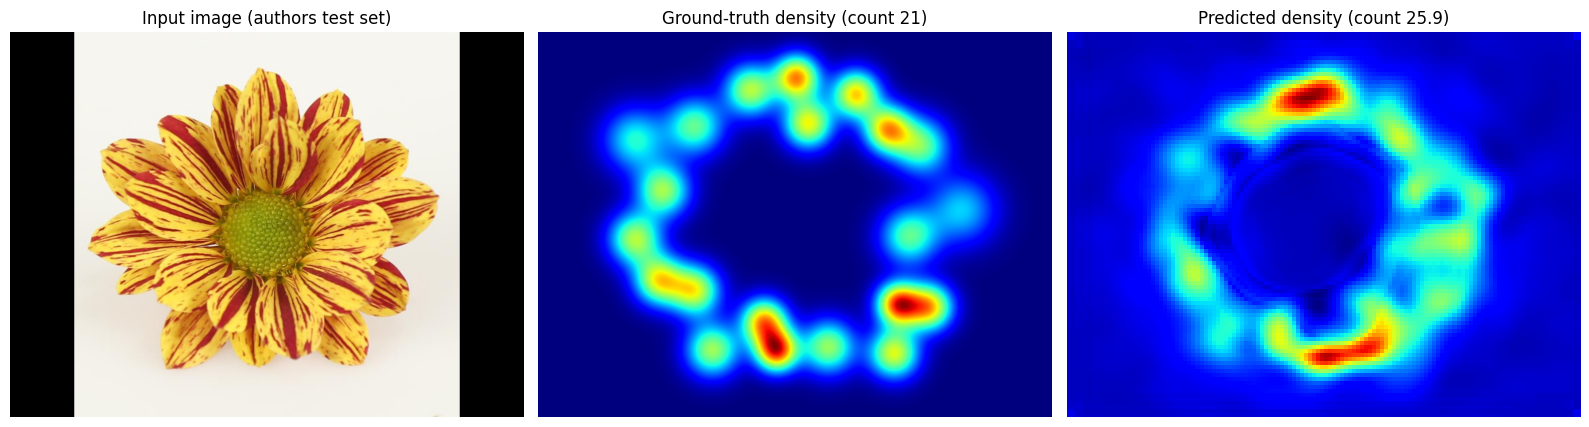

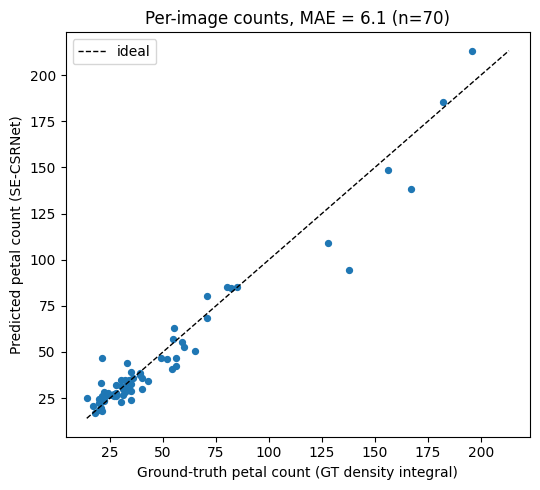

In [ ]:
with torch.no_grad():
    pred_map = model(transform(img).unsqueeze(0).to(device)).squeeze().cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(img); axes[0].set_title('Input image (authors test set)'); axes[0].axis('off')
axes[1].imshow(gt_map, cmap='jet'); axes[1].set_title(f'Ground-truth density (count {gt_map.sum():.0f})'); axes[1].axis('off')
axes[2].imshow(pred_map, cmap='jet'); axes[2].set_title(f'Predicted density (count {pred_map.sum():.1f})'); axes[2].axis('off')
plt.tight_layout(); plt.show()

plt.figure(figsize=(5.5, 5))
plt.scatter(results['ground_truth'], results['predicted'], s=18)
lims = [min(results['ground_truth'].min(), results['predicted'].min()),
        max(results['ground_truth'].max(), results['predicted'].max())]
plt.plot(lims, lims, 'k--', lw=1, label='ideal')
plt.xlabel('Ground-truth petal count (GT density integral)')
plt.ylabel('Predicted petal count (SE-CSRNet)')
plt.title(f'Per-image counts, MAE = {mae:.1f} (n={len(results)})')
plt.legend(); plt.tight_layout(); plt.show()

## 9. Interpretation and provenance

- **What was executed:** the authors' released SE-CSRNet checkpoint (`0model_best.pth.tar`, LFS) and `test.py` procedure on all 70 bundled test images, with per-image and aggregate MAE/MSE/RMSE reported from the actual outputs above.
- **What this validates:** the released inference pipeline reproduces end-to-end on Colab. A single test-set run does not verify the paper's training results, the random-forest calibration stage (its inputs were not released), or the heat-stress analysis.
- **Provenance:** author code and data pinned at commit `fd935c9b8682c9494d9ba36348d7dd364d3eeffa`; authors' README pins torch 2.4.0 / Python 3.10, which current Colab (Python 3.13) cannot install; the preinstalled torch was used and its versions printed above. Adaptations: explicit GPU device selection and torch-version recording — the scientific math is unchanged.
- **References:** Plant Phenomics 8(3):100238 (2026), DOI 10.1016/j.plaphe.2026.100238; repository https://github.com/qwsdfgz/petalscount.

**日本語:** 著者公開のSE-CSRNet重みと`test.py`手順を70枚のテスト画像でそのまま実行しました。学習・RF較正・熱ストレス解析は対象外です。